# Assignment 5: Reducing High-Dimensional Data with PCA

**Student Name:** [Your Name Here]

**Date:** [Date]

---

## Assignment Overview

You've joined the data science team at FitTrack Analytics, a company that develops fall detection systems for elderly care facilities. Their wearable devices capture 561 sensor features from accelerometer and gyroscope readings. Your task: use Principal Component Analysis (PCA) to compress this high-dimensional data into something you can visualize, understand, and build reliable models from.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv('data/train.csv')  # Replace with pd.read_csv()
test_df = pd.read_csv('data/test.csv')   # Replace with pd.read_csv()

# TODO: Separate features from labels
# Create X_train, y_train, X_test, y_test
# The 'Activity' column contains the labels
X_train = train_df.drop('Activity', axis=1)
y_train = train_df['Activity']
X_test = test_df.drop('Activity', axis=1)
y_test = test_df['Activity']



print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape if X_train is not None else 'Not loaded'}")
print(f"Test set shape: {X_test.shape if X_test is not None else 'Not loaded'}")
print(f"Number of features: {X_train.shape[1] if X_train is not None else 'N/A'}")
print(f"Unique activities: {y_train.nunique() if y_train is not None else 'N/A'}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Unique activities: 6


In [3]:
print(y_train.unique())

['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


---
## Step 2: Experience the Problem - Try to Understand 561 Dimensions

### Attempt Visualization with 2 Features

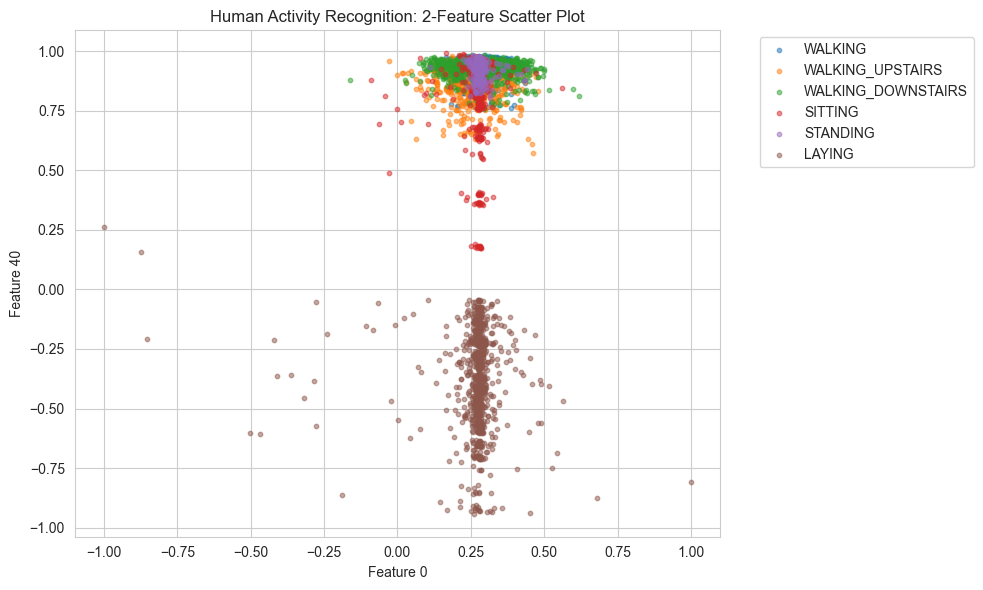

In [4]:
# TODO: Create a scatter plot using any 2 of the 561 features
# Color points by activity type
# Can you see clear patterns separating the six activities?
# Create the scatter plot

activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 
              'SITTING', 'STANDING', 'LAYING']

sample_size = 5000
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train.iloc[sample_indices]
y_sample = y_train.iloc[sample_indices]

plt.figure(figsize=(10, 6))

for activity in activities:
    mask = y_sample == activity        # compare string to string ✅
    plt.scatter(
        X_sample[mask].iloc[:, 0],     # feature 1 (x axis)
        X_sample[mask].iloc[:, 40],    # feature 2 (y axis)
        alpha=0.5, s=10, label=activity
    )

plt.xlabel('Feature 0')
plt.ylabel('Feature 40')
plt.title('Human Activity Recognition: 2-Feature Scatter Plot')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Check Feature Correlations

In [13]:
# TODO: Create a correlation heatmap of all 561 features
# Is it readable? Can you identify redundant features?

# Sample 5000 images to make computation manageable
sample_indices = np.random.choice(len(X_train), 5000, replace=False)
X_sample = X_train.iloc[sample_indices]

# Calculate correlation matrix
corr_matrix = X_sample.T.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix of 784 Features')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')
plt.show()

print(f"Correlation matrix shape: {corr_matrix.shape}")

KeyboardInterrupt: 

### Train Baseline Model

In [5]:
start_time = time.time()

# TODO: Train a RandomForestClassifier with n_estimators=100, random_state=42
# Your code here
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, y_train)


# Calculates baseline training time
baseline_time = time.time() - start_time

# TODO: Calculate accuracy on test set
y_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)


print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print(f"Number of features: {X_train.shape[1]}")
print(f"Accuracy: {baseline_accuracy if baseline_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)


BASELINE MODEL RESULTS
Number of features: 562
Accuracy: 0.9260264675941635
Training time: 3.00 seconds


### Reflection on High-Dimensional Data
In the Markdown cell below this step, write 2-3 sentences responding to the following question: 
- What problems did you encounter trying to understand 561 dimensions?


[Write your response here. Consider: Can you visualize patterns? Is the model interpretable? How long did training take?]
I can not visualize any patterns beacuse of the data, it's hard to see. The model took .5 seconds but the heatmap didn't even charged enough, I was not able to see any correlation

---
## Step 3: Apply PCA to Visualize in 2D and 3D

### Standardize Features

In [6]:
# TODO: Use StandardScaler to normalize all 562 features
# Fit on training data, transform both training and test data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data using scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)   # Replace with scaled test data using scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Scaled training shape: {X_train_scaled.shape if X_train_scaled is not None else 'Not scaled'}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled training shape: (7352, 562)


### Apply PCA for 2 Components

In [7]:
# TODO: Use PCA(n_components=2)
# Fit on standardized training data, transform both sets

pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)   # Replace with PCA-transformed test data using pca_2d.transform(X_test_scaled)

print("\n" + "="*80)
print("PCA TRANSFORMATION TO 2D")
print("="*80)
print(f"Original dimensions: {X_train_scaled.shape[1]}")
print(f"Reduced dimensions: {X_train_pca_2d.shape[1]}")
print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {pca_2d.explained_variance_ratio_.sum():.2%}")
print("="*80)




PCA TRANSFORMATION TO 2D
Original dimensions: 562
Reduced dimensions: 2
Variance explained by PC1: 50.69%
Variance explained by PC2: 6.57%
Total variance explained: 57.26%


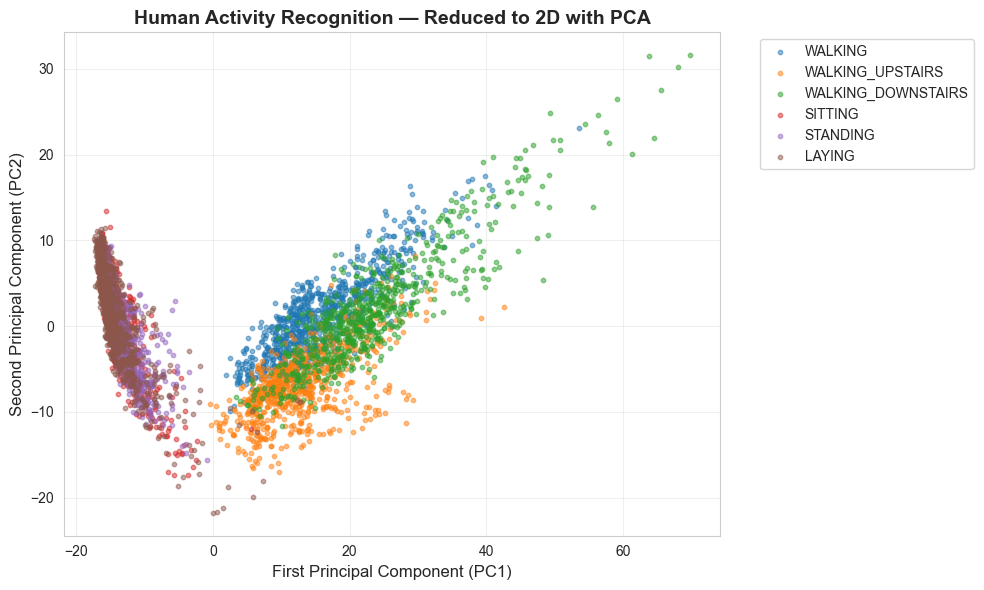

In [ ]:
plt.figure(figsize=(10, 6))

sample_size = 5000
sample_indices = np.random.choice(len(X_train_pca_2d), sample_size, replace=False)
X_sample = X_train_pca_2d[sample_indices]
y_sample = y_train.iloc[sample_indices]

for activity in activities:
    mask = y_sample == activity
    plt.scatter(
        X_sample[mask][:, 0],   
        X_sample[mask][:, 1],   
        alpha=0.5, s=10, label=activity
    )

plt.xlabel('First Principal Component (PC1)', fontsize=12)
plt.ylabel('Second Principal Component (PC2)', fontsize=12)
plt.title('Human Activity Recognition — Reduced to 2D with PCA', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Apply PCA for 3 Components


PCA TRANSFORMATION TO 3D
Variance explained by PC1: 50.69%
Variance explained by PC2: 6.57%
Variance explained by PC3: 2.80%
Total variance explained: 60.06%


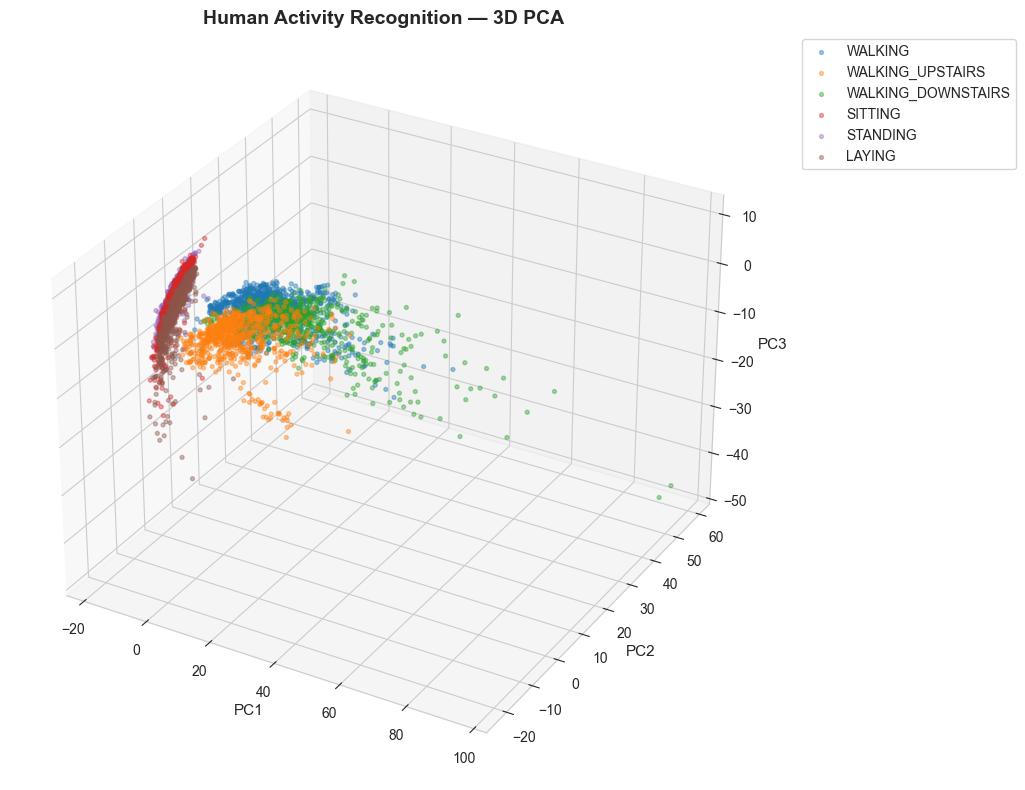

In [14]:
# TODO: Use PCA(n_components=3)
# Fit on standardized training data, transform both sets

pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)   # Replace with PCA-transformed test data using pca_3d.transform(X_test_scaled)

print("\n" + "="*80)
print("PCA TRANSFORMATION TO 3D")
print("="*80)
print(f"Variance explained by PC1: {pca_3d.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca_3d.explained_variance_ratio_[1]:.2%}")
print(f"Variance explained by PC3: {pca_3d.explained_variance_ratio_[2]:.2%}")
print(f"Total variance explained: {pca_3d.explained_variance_ratio_.sum():.2%}")
print("="*80)
# TODO: Create 3D scatter plot using the 3 principal components
# Use mpl_toolkits.mplot3d.Axes3D
# Color by activity type
# Sample 5000 points
sample_size = 5000
sample_indices = np.random.choice(len(X_train_pca_3d), sample_size, replace=False)
X_sample = X_train_pca_3d[sample_indices]
y_sample = y_train.iloc[sample_indices]

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for activity in activities:
    mask = y_sample == activity
    ax.scatter(
        X_sample[mask][:, 0],   # PC1
        X_sample[mask][:, 1],   # PC2
        X_sample[mask][:, 2],   # PC3 — the new dimension
        alpha=0.4, s=8, label=activity
    )

ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_zlabel('PC3', fontsize=11)
ax.set_title('Human Activity Recognition — 3D PCA', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Reflection on PCA Visualization
In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- What activity patterns can you now see? 
- Which activities cluster together?

Laying, standing, sitting are the ones that you can see cluster the most because I magine the body more or less reacts the same to these situations and of course walking

---
## Step 4: Determine Optimal Number of Components Using Explained Variance

### Create Scree Plot

EXPLAINED VARIANCE BY COMPONENT
Total components available: 100

PC1   explains: 50.69% of variance
PC2   explains: 6.57% of variance
PC3   explains: 2.80% of variance
PC4   explains: 2.50% of variance
PC5   explains: 1.88% of variance
...
PC50  explains: 0.23% of variance
PC100 explains: 0.10% of variance


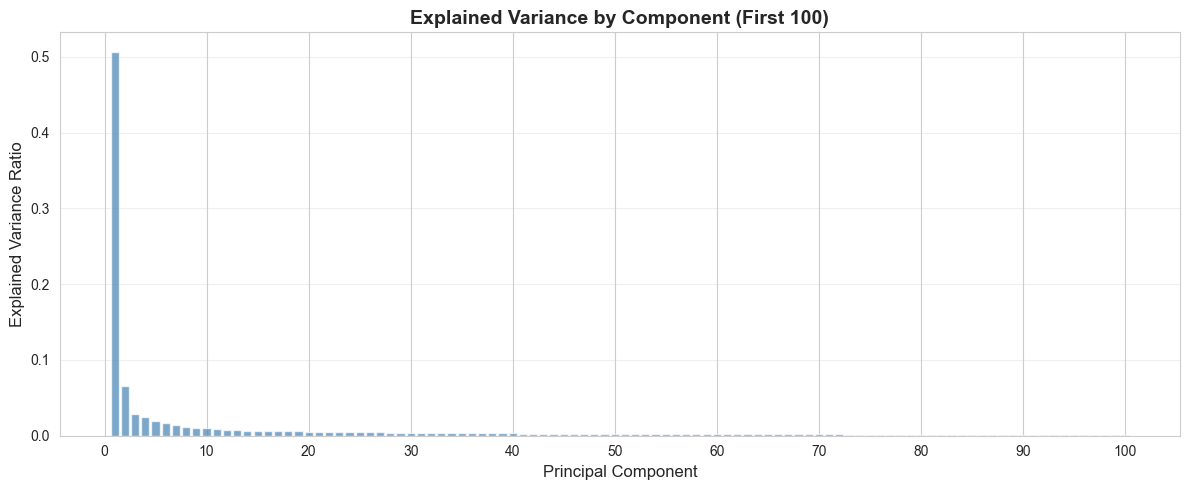

In [23]:
# Fit PCA(n_components=100) to standardized training data
pca_full = PCA(n_components=100)
pca_full.fit(X_train_scaled)

# Your code here
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)  # ✅ cumulative sum
n_components_total = len(explained_variance)

print("="*80)
print("EXPLAINED VARIANCE BY COMPONENT")
print("="*80)
print(f"Total components available: {n_components_total}")
print(f"\nPC1   explains: {explained_variance[0]:.2%} of variance")
print(f"PC2   explains: {explained_variance[1]:.2%} of variance")
print(f"PC3   explains: {explained_variance[2]:.2%} of variance")
print(f"PC4   explains: {explained_variance[3]:.2%} of variance")
print(f"PC5   explains: {explained_variance[4]:.2%} of variance")
print(f"...")
print(f"PC50  explains: {explained_variance[49]:.2%} of variance")
print(f"PC100 explains: {explained_variance[99]:.2%} of variance")  # ✅ removed PC200
print("="*80)



# TODO: Plot explained variance ratio for each component
# Use pca_full.explained_variance_ratio_ to get the ratios
# Use np.cumsum() to compute cumulative variance 



# TODO: Plot cumulative explained variance

plt.figure(figsize=(12, 5))
plt.bar(range(1, 101), explained_variance, alpha=0.7, color='steelblue')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Explained Variance by Component (First 100)', fontsize=14, fontweight='bold')
plt.xticks(range(0, 101, 10))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Analyze the Elbow

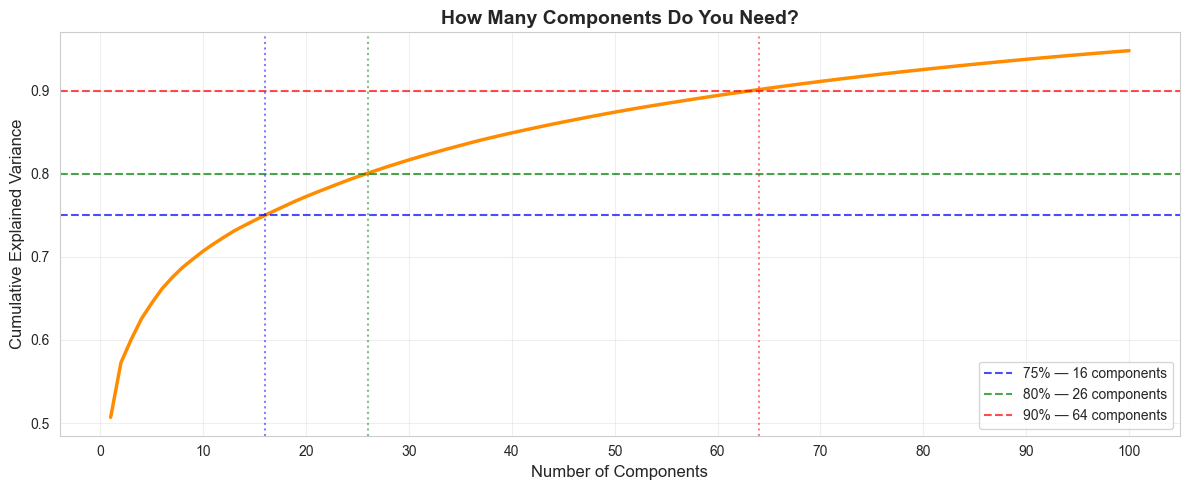


EXPLAINED VARIANCE ANALYSIS
Components for 75% variance: 16
Components for 80% variance: 26
Components for 90% variance: 64


In [22]:
# Calculate components needed for each threshold
components_75 = np.argmax(cumulative_variance >= 0.75) + 1
components_80 = np.argmax(cumulative_variance >= 0.80) + 1
components_90 = np.argmax(cumulative_variance >= 0.90) + 1

plt.figure(figsize=(12, 5))
plt.plot(range(1, 101), cumulative_variance, color='darkorange', linewidth=2.5)

# Threshold lines
plt.axhline(y=0.75, color='blue',  linestyle='--', alpha=0.7, label=f'75% — {components_75} components')
plt.axhline(y=0.80, color='green', linestyle='--', alpha=0.7, label=f'80% — {components_80} components')
plt.axhline(y=0.90, color='red',   linestyle='--', alpha=0.7, label=f'90% — {components_90} components')

# Vertical marker lines dropping down to x axis
plt.axvline(x=components_75, color='blue',  linestyle=':', alpha=0.5)
plt.axvline(x=components_80, color='green', linestyle=':', alpha=0.5)
plt.axvline(x=components_90, color='red',   linestyle=':', alpha=0.5)

plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('How Many Components Do You Need?', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(range(0, 101, 10))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("EXPLAINED VARIANCE ANALYSIS")
print(f"Components for 75% variance: {components_75}")
print(f"Components for 80% variance: {components_80}")
print(f"Components for 90% variance: {components_90}")
print("="*80)

### Select Optimal Components

In [26]:
# TODO: Set your chosen optimal number of components
optimal_components = components_80    # Replace with your chosen value (components_75, components_80, or components_90)
print(f"Chosen number of components: {optimal_components}")

Chosen number of components: 26


In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- How many components did you select based on the elbow? 
- What percentage of variance does this capture? 
- What's the tradeoff?

26 because  it rises steeply until around component 20–30, then flattens out significantly. 80% of the variance is captured. And the model is going to be slower

---
## Step 5: Compare Model Performance - Original vs PCA Features

### Transform Data with Optimal Components

In [27]:
# TODO: Apply PCA with your optimal number of components
# Fit on standardized training data, transform both sets

pca_optimal = PCA(n_components=optimal_components)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data
X_test_pca = pca_optimal.transform(X_test_scaled)   # Replace with PCA-transformed test data

print("\n" + "="*80)
print("CHECKPOINT: Data Transformed with Optimal Components")
print(f"New feature dimensions: {X_train_pca.shape if X_train_pca is not None else 'Not transformed'}")
print("="*80)


CHECKPOINT: Data Transformed with Optimal Components
New feature dimensions: (7352, 26)


### Train PCA Model

In [28]:
# To measure training time
start_time = time.time()

# TODO: Train RandomForestClassifier with same parameters
# Use n_estimators=100, random_state=42
# Use X_train_pca and y_train
pca_model = RandomForestClassifier(n_estimators=100, random_state=42)
pca_model.fit(X_train_pca, y_train)


# TODO: Calculate accuracy on test set
pca_accuracy = accuracy_score(y_test, pca_model.predict(X_test_pca))


# Record: accuracy, training time, number of features
pca_time = time.time() - start_time
print("\n" + "="*80)
print("PCA MODEL RESULTS")
print(f"Number of features: {optimal_components}")
print(f"Accuracy: {pca_accuracy if pca_accuracy else 'Not calculated'}")
print(f"Training time: {pca_time:.2f} seconds")
print("="*80)


PCA MODEL RESULTS
Number of features: 26
Accuracy: 0.8747879199185612
Training time: 3.43 seconds


### Create Comparison Table

In [29]:
# Create comparison table showing:
# - Number of features
# - Accuracy
# - Training time

comparison_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', 'PCA Model'],
    'Features': [561, optimal_components],
    'Accuracy': [baseline_accuracy, pca_accuracy],
    'Training Time (s)': [baseline_time, pca_time]
})

# TODO: Calculate speedup factor
speedup = baseline_time / pca_time  # Replace with baseline_time / pca_time

comparison_df['Accuracy'] = comparison_df['Accuracy'].apply(lambda x: f"{x*100:.2f}%")
comparison_df['Training Time (s)'] = comparison_df['Training Time (s)'].apply(lambda x: f"{x:.2f}s")


print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nSpeedup factor: {speedup:.2f}x" if speedup else "\nSpeedup not calculated")
print("="*80)


MODEL COMPARISON
                  Model  Features Accuracy Training Time (s)
Baseline (All Features)       561   92.60%             3.00s
              PCA Model        26   87.48%             3.43s

Speedup factor: 0.88x


### Final Analysis

    In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
    - Did PCA improve or hurt accuracy? 
    - How much faster was training? 
    - When would you recommend using PCA?

Surprisingly the PCA model reduced accuracy from 92.60% to 87.48% and was slower. This probaly happened because the database is small enough for the random forest to manage. PCA probably performs better with images when processing actually takes more time

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline model with metrics recorded
   - 2D and 3D PCA visualizations
   - Scree plot with explained variance
   - Optimal component selection with justification
   - Model comparison table
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed PCA dimensionality reduction assignment'
git push
```

Submit your GitHub repository link on the course platform.